In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
# Load the transaction dataset
df = pd.read_csv("../data/raw/payment_transactions.csv")

print("Dataset loaded successfully!")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Dataset loaded successfully!
Rows: 10,000
Columns: 15


In [8]:
df.head()

,transaction_id,customer_id,amount,payment_method,failure_reason,retry_count,previous_success_count,previous_failure_count,historical_success_rate,device_type,channel,transaction_hour,recovery_probability,recovered,recovered_amount
0,TXN_000001,861,324.69,Credit Card,Expired Card,1,9,2,0.818182,Mobile,App,21,0.382597,1,324.69
1,TXN_000002,1295,100.00,UPI,Authentication Failure,3,5,0,1.000000,Desktop,App,19,0.652250,1,100.00
2,TXN_000003,1131,599.10,Credit Card,Insufficient Funds,1,10,1,0.909091,Desktop,App,11,0.536457,1,599.10
3,TXN_000004,1096,2485.04,UPI,Gateway Error,2,9,1,0.900000,Mobile,Web,12,0.756287,1,2485.04
4,TXN_000005,1639,683.79,Net Banking,Gateway Error,2,4,4,0.500000,Mobile,App,19,0.520791,1,683.79


In [9]:
# Display all dataset columns
print("Dataset columns:")
for column in df.columns:
    print("-", column)

Dataset columns:
- transaction_id
- customer_id
- amount
- payment_method
- failure_reason
- retry_count
- previous_success_count
- previous_failure_count
- historical_success_rate
- device_type
- channel
- transaction_hour
- recovery_probability
- recovered
- recovered_amount


In [10]:
# Inspect dataset structure
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_id           10000 non-null  str    
 1   customer_id              10000 non-null  int64  
 2   amount                   10000 non-null  float64
 3   payment_method           10000 non-null  str    
 4   failure_reason           10000 non-null  str    
 5   retry_count              10000 non-null  int64  
 6   previous_success_count   10000 non-null  int64  
 7   previous_failure_count   10000 non-null  int64  
 8   historical_success_rate  10000 non-null  float64
 9   device_type              10000 non-null  str    
 10  channel                  10000 non-null  str    
 11  transaction_hour         10000 non-null  int64  
 12  recovery_probability     10000 non-null  float64
 13  recovered                10000 non-null  int64  
 14  recovered_amount         10000 non

In [11]:
# Check for missing values
missing_values = df.isnull().sum()

print("Missing values per column:")
print(missing_values)

Missing values per column:
transaction_id             0
customer_id                0
amount                     0
payment_method             0
failure_reason             0
retry_count                0
previous_success_count     0
previous_failure_count     0
historical_success_rate    0
device_type                0
channel                    0
transaction_hour           0
recovery_probability       0
recovered                  0
recovered_amount           0
dtype: int64


In [12]:
# Check for duplicate records
print("Duplicate rows:", df.duplicated().sum())
print(
    "Duplicate transaction IDs:",
    df["transaction_id"].duplicated().sum()
)

Duplicate rows: 0
Duplicate transaction IDs: 0


In [13]:
# Overall recovery analysis

total_transactions = len(df)

recovered_transactions = df["recovered"].sum()

recovery_rate = (
    recovered_transactions / total_transactions
) * 100

total_transaction_value = df["amount"].sum()

total_recovered_revenue = df["recovered_amount"].sum()

total_unrecovered_revenue = (
    total_transaction_value - total_recovered_revenue
)

print(f"Total transactions: {total_transactions:,}")
print(f"Recovered transactions: {recovered_transactions:,}")
print(f"Recovery rate: {recovery_rate:.2f}%")
print(f"Total transaction value: ₹{total_transaction_value:,.2f}")
print(f"Recovered revenue: ₹{total_recovered_revenue:,.2f}")
print(f"Unrecovered revenue: ₹{total_unrecovered_revenue:,.2f}")

Total transactions: 10,000
Recovered transactions: 6,104
Recovery rate: 61.04%
Total transaction value: ₹9,130,307.35
Recovered revenue: ₹5,491,815.11
Unrecovered revenue: ₹3,638,492.24


In [14]:
# Recovery performance by failure reason

failure_analysis = (
    df.groupby("failure_reason")
    .agg(
        transactions=("transaction_id", "count"),
        recovered_transactions=("recovered", "sum"),
        transaction_value=("amount", "sum"),
        recovered_revenue=("recovered_amount", "sum")
    )
    .reset_index()
)

failure_analysis["recovery_rate"] = (
    failure_analysis["recovered_transactions"]
    / failure_analysis["transactions"]
) * 100

failure_analysis["unrecovered_revenue"] = (
    failure_analysis["transaction_value"]
    - failure_analysis["recovered_revenue"]
)

failure_analysis.sort_values(
    "unrecovered_revenue",
    ascending=False
)

,failure_reason,transactions,recovered_transactions,transaction_value,recovered_revenue,recovery_rate,unrecovered_revenue
4,Insufficient Funds,1957,915,1856947.38,854891.99,46.755238,1002055.39
1,Bank Decline,1558,762,1400545.73,662649.02,48.908858,737896.71
2,Expired Card,947,328,859745.84,293093.48,34.635692,566652.36
0,Authentication Failure,1543,1009,1420493.66,926221.39,65.392093,494272.27
3,Gateway Error,1993,1501,1796163.95,1329082.39,75.313598,467081.56
5,Network Timeout,2002,1589,1796410.79,1425876.84,79.370629,370533.95


In [15]:
# Display failure analysis clearly

print(
    failure_analysis[
        [
            "failure_reason",
            "transactions",
            "recovered_transactions",
            "recovery_rate",
            "transaction_value",
            "recovered_revenue",
            "unrecovered_revenue"
        ]
    ]
    .sort_values("unrecovered_revenue", ascending=False)
    .to_string(index=False)
)

        failure_reason  transactions  recovered_transactions  recovery_rate  transaction_value  recovered_revenue  unrecovered_revenue
    Insufficient Funds          1957                     915      46.755238         1856947.38          854891.99           1002055.39
          Bank Decline          1558                     762      48.908858         1400545.73          662649.02            737896.71
          Expired Card           947                     328      34.635692          859745.84          293093.48            566652.36
Authentication Failure          1543                    1009      65.392093         1420493.66          926221.39            494272.27
         Gateway Error          1993                    1501      75.313598         1796163.95         1329082.39            467081.56
       Network Timeout          2002                    1589      79.370629         1796410.79         1425876.84            370533.95


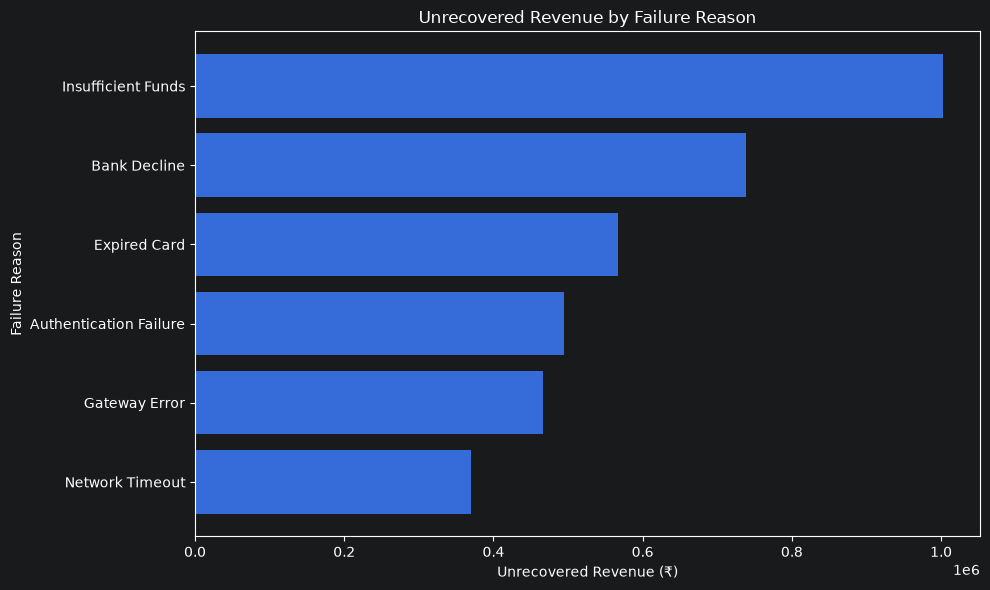

In [16]:
# Unrecovered revenue by failure reason

plot_data = failure_analysis.sort_values(
    "unrecovered_revenue",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_data["failure_reason"],
    plot_data["unrecovered_revenue"]
)

plt.xlabel("Unrecovered Revenue (₹)")
plt.ylabel("Failure Reason")
plt.title("Unrecovered Revenue by Failure Reason")

plt.tight_layout()
plt.show()

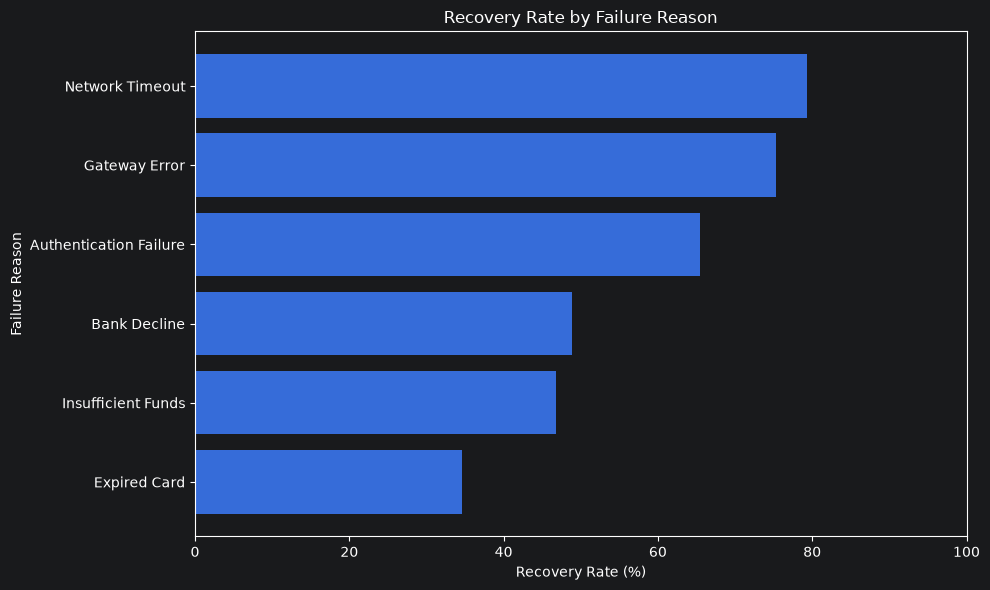

In [17]:
# Recovery rate by failure reason

plot_data = failure_analysis.sort_values(
    "recovery_rate",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_data["failure_reason"],
    plot_data["recovery_rate"]
)

plt.xlabel("Recovery Rate (%)")
plt.ylabel("Failure Reason")
plt.title("Recovery Rate by Failure Reason")

plt.xlim(0, 100)

plt.tight_layout()
plt.show()

In [18]:
# Recovery rate by retry count

retry_analysis = (
    df.groupby("retry_count")
    .agg(
        transactions=("transaction_id", "count"),
        recovered_transactions=("recovered", "sum"),
        transaction_value=("amount", "sum"),
        recovered_revenue=("recovered_amount", "sum")
    )
    .reset_index()
)

retry_analysis["recovery_rate"] = (
    retry_analysis["recovered_transactions"]
    / retry_analysis["transactions"]
) * 100

retry_analysis

,retry_count,transactions,recovered_transactions,transaction_value,recovered_revenue,recovery_rate
0,0,3014,2102,2803127.58,1913498.99,69.741208
1,1,3607,2218,3267604.77,1979375.66,61.491544
2,2,2196,1213,1972052.96,1075127.75,55.236794
3,3,866,431,780000.32,381053.79,49.769053
4,4,235,108,229003.52,108987.99,45.957447
5,5,82,32,78518.20,33770.93,39.024390


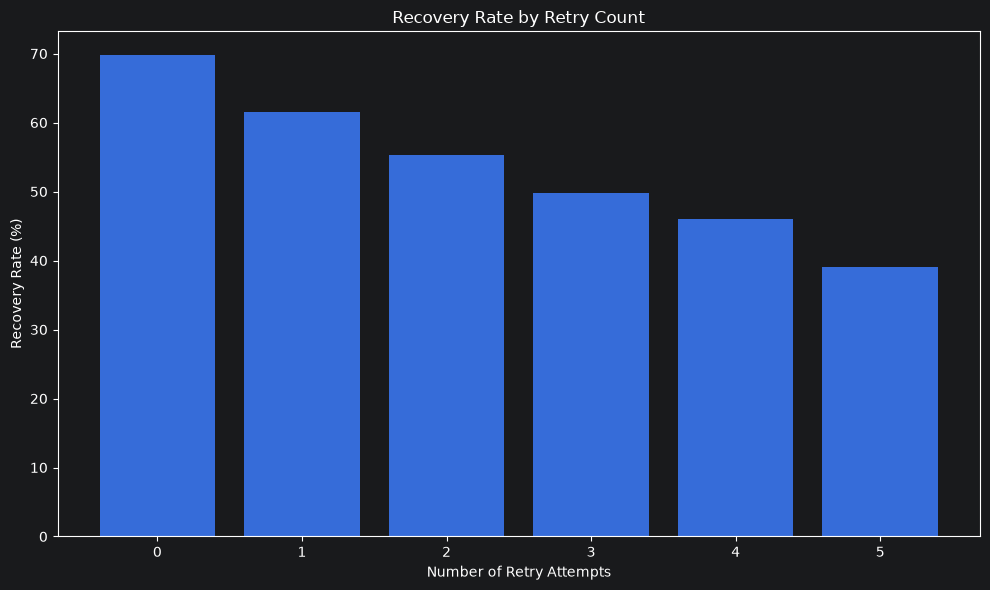

In [19]:
# Visualize recovery rate by retry count

plt.figure(figsize=(10, 6))

plt.bar(
    retry_analysis["retry_count"],
    retry_analysis["recovery_rate"]
)

plt.xlabel("Number of Retry Attempts")
plt.ylabel("Recovery Rate (%)")
plt.title("Recovery Rate by Retry Count")

plt.xticks(retry_analysis["retry_count"])

plt.tight_layout()
plt.show()

In [20]:
# Recovery performance by payment method

payment_method_analysis = (
    df.groupby("payment_method")
    .agg(
        transactions=("transaction_id", "count"),
        recovered_transactions=("recovered", "sum"),
        transaction_value=("amount", "sum"),
        recovered_revenue=("recovered_amount", "sum")
    )
    .reset_index()
)

payment_method_analysis["recovery_rate"] = (
    payment_method_analysis["recovered_transactions"]
    / payment_method_analysis["transactions"]
) * 100

payment_method_analysis.sort_values(
    "recovery_rate",
    ascending=False
)

,payment_method,transactions,recovered_transactions,transaction_value,recovered_revenue,recovery_rate
4,Wallet,492,316,452077.83,281118.34,64.227642
3,UPI,4487,2757,4078897.98,2477984.02,61.444172
2,Net Banking,992,608,907974.46,554202.86,61.290323
0,Credit Card,2484,1497,2248982.80,1337643.54,60.265700
1,Debit Card,1545,926,1442374.28,840866.35,59.935275


In [21]:
# Display only the important payment-method metrics

print(
    payment_method_analysis[
        [
            "payment_method",
            "transactions",
            "recovered_transactions",
            "recovery_rate",
            "transaction_value",
            "recovered_revenue"
        ]
    ]
    .sort_values("recovery_rate", ascending=False)
    .to_string(index=False)
)

payment_method  transactions  recovered_transactions  recovery_rate  transaction_value  recovered_revenue
        Wallet           492                     316      64.227642          452077.83          281118.34
           UPI          4487                    2757      61.444172         4078897.98         2477984.02
   Net Banking           992                     608      61.290323          907974.46          554202.86
   Credit Card          2484                    1497      60.265700         2248982.80         1337643.54
    Debit Card          1545                     926      59.935275         1442374.28          840866.35


In [22]:
print(
    payment_method_analysis[
        ["payment_method", "recovery_rate"]
    ]
    .sort_values("recovery_rate", ascending=False)
    .to_string(index=False)
)

payment_method  recovery_rate
        Wallet      64.227642
           UPI      61.444172
   Net Banking      61.290323
   Credit Card      60.265700
    Debit Card      59.935275


In [23]:
# Analyze recovery by transaction amount

df["amount_bucket"] = pd.cut(
    df["amount"],
    bins=[0, 500, 1000, 5000, 10000, 50000],
    labels=[
        "₹0-500",
        "₹500-1K",
        "₹1K-5K",
        "₹5K-10K",
        "₹10K-50K"
    ]
)

amount_analysis = (
    df.groupby("amount_bucket", observed=False)
    .agg(
        transactions=("transaction_id", "count"),
        recovered_transactions=("recovered", "sum"),
        transaction_value=("amount", "sum"),
        recovered_revenue=("recovered_amount", "sum")
    )
    .reset_index()
)

amount_analysis["recovery_rate"] = (
    amount_analysis["recovered_transactions"]
    / amount_analysis["transactions"]
) * 100

amount_analysis

,amount_bucket,transactions,recovered_transactions,transaction_value,recovered_revenue,recovery_rate
0,₹0-500,3607,2248,1130823.16,700581.83,62.323260
1,₹500-1K,3359,2024,2419930.59,1456094.55,60.256029
2,₹1K-5K,2978,1796,5222933.51,3114201.80,60.308932
3,₹5K-10K,55,35,345357.69,209674.53,63.636364
4,₹10K-50K,1,1,11262.40,11262.40,100.000000


In [24]:
# Check the current dataset columns
print(df.columns.tolist())

['transaction_id', 'customer_id', 'amount', 'payment_method', 'failure_reason', 'retry_count', 'previous_success_count', 'previous_failure_count', 'historical_success_rate', 'device_type', 'channel', 'transaction_hour', 'recovery_probability', 'recovered', 'recovered_amount', 'amount_bucket']


In [25]:
# Define features for the recovery model

features = [
    "amount",
    "payment_method",
    "failure_reason",
    "retry_count",
    "previous_success_count",
    "previous_failure_count",
    "historical_success_rate",
    "device_type",
    "channel",
    "transaction_hour"
]

target = "recovered"

X = df[features].copy()
y = df[target].copy()

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(target)

print("\nFeature shape:", X.shape)
print("Target shape:", y.shape)

Features:
['amount', 'payment_method', 'failure_reason', 'retry_count', 'previous_success_count', 'previous_failure_count', 'historical_success_rate', 'device_type', 'channel', 'transaction_hour']

Target:
recovered

Feature shape: (10000, 10)
Target shape: (10000,)


In [26]:
from sklearn.model_selection import train_test_split

# Split the data into training and held-out test sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Test samples:", len(X_test))

print("\nTraining recovery rate:", y_train.mean())
print("Test recovery rate:", y_test.mean())

Training samples: 8000
Test samples: 2000

Training recovery rate: 0.610375
Test recovery rate: 0.6105


In [27]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

# Numerical features
numeric_features = [
    "amount",
    "retry_count",
    "previous_success_count",
    "previous_failure_count",
    "historical_success_rate",
    "transaction_hour"
]

# Categorical features
categorical_features = [
    "payment_method",
    "failure_reason",
    "device_type",
    "channel"
]

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            "passthrough",
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [28]:
from sklearn.linear_model import LogisticRegression

# Create the ML pipeline
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

# Train the model
logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


D:\RazorpayBuildathon\RecoverAI\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [29]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# Numerical features
numeric_features = [
    "amount",
    "retry_count",
    "previous_success_count",
    "previous_failure_count",
    "historical_success_rate",
    "transaction_hour"
]

# Categorical features
categorical_features = [
    "payment_method",
    "failure_reason",
    "device_type",
    "channel"
]

# Improved preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

print("Improved preprocessing pipeline created successfully.")

Improved preprocessing pipeline created successfully.


In [30]:
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=2000,
                random_state=42
            )
        )
    ]
)

logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [31]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# Predictions on the held-out test set
y_pred = logistic_model.predict(X_test)

# Recovery probabilities
y_probability = logistic_model.predict_proba(X_test)[:, 1]

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_probability)

print("MODEL PERFORMANCE")
print("=" * 40)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

MODEL PERFORMANCE
Accuracy : 0.6695
Precision: 0.7011
Recall   : 0.7993
F1 Score : 0.7470
ROC-AUC  : 0.7146

Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.47      0.52       779
           1       0.70      0.80      0.75      1221

    accuracy                           0.67      2000
   macro avg       0.65      0.63      0.64      2000
weighted avg       0.66      0.67      0.66      2000



In [32]:
print("FINAL BASELINE METRICS")
print("=" * 40)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

FINAL BASELINE METRICS
Accuracy : 0.6695
Precision: 0.7011
Recall   : 0.7993
F1 Score : 0.7470
ROC-AUC  : 0.7146


In [33]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest pipeline
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=12,
                min_samples_leaf=5,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

# Train Random Forest
random_forest_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [34]:
# Random Forest predictions

rf_pred = random_forest_model.predict(X_test)

# Recovery probabilities
rf_probability = random_forest_model.predict_proba(X_test)[:, 1]

# Calculate metrics
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_roc_auc = roc_auc_score(y_test, rf_probability)

print("RANDOM FOREST PERFORMANCE")
print("=" * 40)
print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1 Score : {rf_f1:.4f}")
print(f"ROC-AUC  : {rf_roc_auc:.4f}")

RANDOM FOREST PERFORMANCE
Accuracy : 0.6635
Precision: 0.6957
Recall   : 0.7977
F1 Score : 0.7432
ROC-AUC  : 0.7025


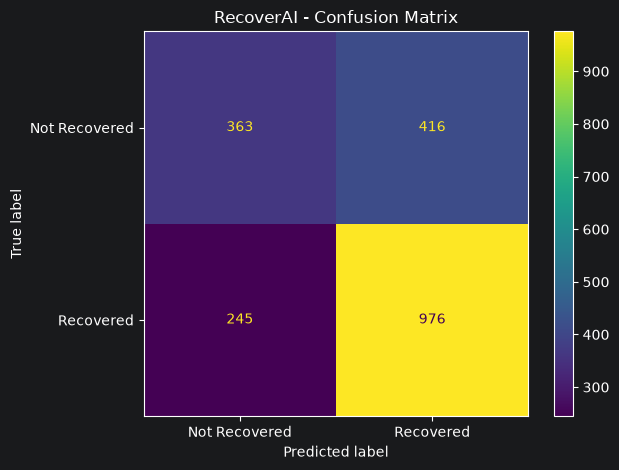

In [35]:
from sklearn.metrics import ConfusionMatrixDisplay

# Confusion matrix for final Logistic Regression model

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Not Recovered", "Recovered"]
)

plt.title("RecoverAI - Confusion Matrix")
plt.tight_layout()
plt.show()

In [36]:
def recovery_decision(probability):
    """
    Convert recovery probability into an action.
    """

    if probability >= 0.75:
        return "RETRY_NOW"

    elif probability >= 0.50:
        return "ALTERNATE_ACTION"

    else:
        return "STOP"


# Test the decision engine
test_probabilities = [0.90, 0.72, 0.55, 0.35]

for probability in test_probabilities:
    action = recovery_decision(probability)

    print(
        f"Recovery Probability: {probability:.2f}"
        f" -> Action: {action}"
    )

Recovery Probability: 0.90 -> Action: RETRY_NOW
Recovery Probability: 0.72 -> Action: ALTERNATE_ACTION
Recovery Probability: 0.55 -> Action: ALTERNATE_ACTION
Recovery Probability: 0.35 -> Action: STOP


In [37]:
def get_recovery_action(probability, failure_reason):
    """
    Decide the best recovery action based on
    recovery probability and payment failure reason.
    """

    # High probability → retry immediately
    if probability >= 0.75:
        return "RETRY_NOW"

    # Medium probability → choose an alternate recovery strategy
    elif probability >= 0.50:

        if failure_reason == "Network Timeout":
            return "RETRY_LATER"

        elif failure_reason == "Gateway Error":
            return "RETRY_WITH_ALTERNATE_GATEWAY"

        elif failure_reason == "Authentication Failure":
            return "REQUEST_AUTHENTICATION"

        elif failure_reason == "Insufficient Funds":
            return "SUGGEST_ALTERNATE_PAYMENT"

        elif failure_reason == "Expired Card":
            return "REQUEST_CARD_UPDATE"

        elif failure_reason == "Bank Decline":
            return "SUGGEST_ALTERNATE_PAYMENT"

    # Low probability → don't waste another recovery attempt
    return "STOP"


# Test the recovery agent
test_cases = [
    (0.90, "Network Timeout"),
    (0.72, "Insufficient Funds"),
    (0.65, "Authentication Failure"),
    (0.55, "Expired Card"),
    (0.35, "Bank Decline")
]

for probability, failure_reason in test_cases:

    action = get_recovery_action(
        probability,
        failure_reason
    )

    print(
        f"Probability: {probability:.2f} | "
        f"Failure: {failure_reason} | "
        f"Action: {action}"
    )

Probability: 0.90 | Failure: Network Timeout | Action: RETRY_NOW
Probability: 0.72 | Failure: Insufficient Funds | Action: SUGGEST_ALTERNATE_PAYMENT
Probability: 0.65 | Failure: Authentication Failure | Action: REQUEST_AUTHENTICATION
Probability: 0.55 | Failure: Expired Card | Action: REQUEST_CARD_UPDATE
Probability: 0.35 | Failure: Bank Decline | Action: STOP


In [38]:
# Select one unseen transaction from the test set

sample_index = X_test.index[0]

sample_transaction = X_test.loc[[sample_index]]

# Get recovery probability from the trained ML model
sample_probability = logistic_model.predict_proba(
    sample_transaction
)[0, 1]

# Get the actual failure reason
sample_failure_reason = df.loc[
    sample_index,
    "failure_reason"
]

# Generate recovery action
sample_action = get_recovery_action(
    sample_probability,
    sample_failure_reason
)

print("========== RecoverAI Agent ==========")
print(f"Transaction ID   : {df.loc[sample_index, 'transaction_id']}")
print(f"Amount           : ₹{df.loc[sample_index, 'amount']:.2f}")
print(f"Payment Method   : {df.loc[sample_index, 'payment_method']}")
print(f"Failure Reason   : {sample_failure_reason}")
print(f"Retry Count      : {df.loc[sample_index, 'retry_count']}")
print(f"Recovery Score   : {sample_probability:.4f}")
print(f"Recommended Action: {sample_action}")

========== RecoverAI Agent ==========
Transaction ID   : TXN_001332
Amount           : ₹341.60
Payment Method   : UPI
Failure Reason   : Gateway Error
Retry Count      : 1
Recovery Score   : 0.7472
Recommended Action: RETRY_WITH_ALTERNATE_GATEWAY


In [39]:
# Calculate expected recoverable revenue for test transactions

test_results = X_test.copy()

test_results["recovery_probability"] = (
    logistic_model.predict_proba(X_test)[:, 1]
)

test_results["amount"] = df.loc[
    X_test.index,
    "amount"
]

test_results["failure_reason"] = df.loc[
    X_test.index,
    "failure_reason"
]

test_results["expected_revenue"] = (
    test_results["amount"]
    * test_results["recovery_probability"]
)

# Rank transactions by expected recoverable revenue
priority_transactions = (
    test_results
    .sort_values(
        "expected_revenue",
        ascending=False
    )
    .head(10)
)

print("TOP 10 RECOVERY OPPORTUNITIES")
print("=" * 70)

print(
    priority_transactions[
        [
            "amount",
            "failure_reason",
            "recovery_probability",
            "expected_revenue"
        ]
    ].to_string(index=False)
)

TOP 10 RECOVERY OPPORTUNITIES
 amount         failure_reason  recovery_probability  expected_revenue
8556.15          Gateway Error              0.741631       6345.507467
9290.28          Gateway Error              0.646620       6007.284645
8151.42        Network Timeout              0.699063       5698.359712
6367.64        Network Timeout              0.769212       4898.063631
5806.91        Network Timeout              0.712830       4139.339568
4993.89        Network Timeout              0.810633       4048.210916
5059.53        Network Timeout              0.768025       3885.843262
6127.23 Authentication Failure              0.578360       3543.746699
4453.83        Network Timeout              0.763977       3402.624719
4373.41          Gateway Error              0.747322       3268.346271


In [40]:
from src.models.recovery_model import create_model, train_model

print("RecoverAI model module imported successfully.")

RecoverAI model module imported successfully.


In [41]:
# Train RecoverAI model using the reusable model module

final_model = train_model(
    X_train,
    y_train
)

print("RecoverAI model trained successfully.")

RecoverAI model trained successfully.


In [42]:
# Train RecoverAI model using the reusable model module

final_model = train_model(
    X_train,
    y_train
)

print("RecoverAI model trained successfully.")

RecoverAI model trained successfully.


In [43]:
# Evaluate the reusable RecoverAI model

final_predictions = final_model.predict(X_test)

final_accuracy = accuracy_score(
    y_test,
    final_predictions
)

print(f"Final Model Accuracy: {final_accuracy:.4f}")

Final Model Accuracy: 0.6695


In [44]:
import joblib
from pathlib import Path

# Create models directory if it doesn't exist
model_dir = Path("../src/models")
model_dir.mkdir(parents=True, exist_ok=True)

# Save trained model
model_path = model_dir / "recovery_model.pkl"

joblib.dump(final_model, model_path)

print(f"Model saved successfully: {model_path}")

Model saved successfully: ..\src\models\recovery_model.pkl
